Barrir function $\hat I_t (u) = - 1/t \cdot \log(-u)$.

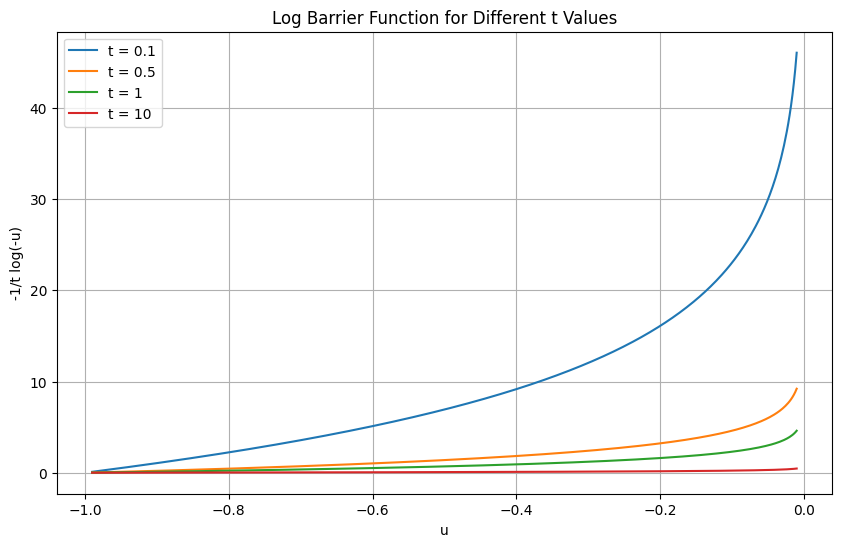

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the log barrier function
def log_barrier(u, t):
    return -1/t * np.log(-u)

# Define values of u close to the boundary (approaching from the left to -0)
u_values = np.linspace(-0.99, -0.01, 500)

# Different values of t to show the effect on the barrier function
t_values = [.1, .5, 1, 10]

plt.figure(figsize=(10, 6))

for t in t_values:
    plt.plot(u_values, log_barrier(u_values, t), label=f't = {t}')

plt.title('Log Barrier Function for Different t Values')
plt.xlabel('u')
plt.ylabel('-1/t log(-u)')
plt.legend()
plt.grid(True)
plt.show()


$\min f(x ) = | a x - b|^2 $ subject to $|x|^2 \leq 1$. We plot the barrier function objective for different values of $t$.

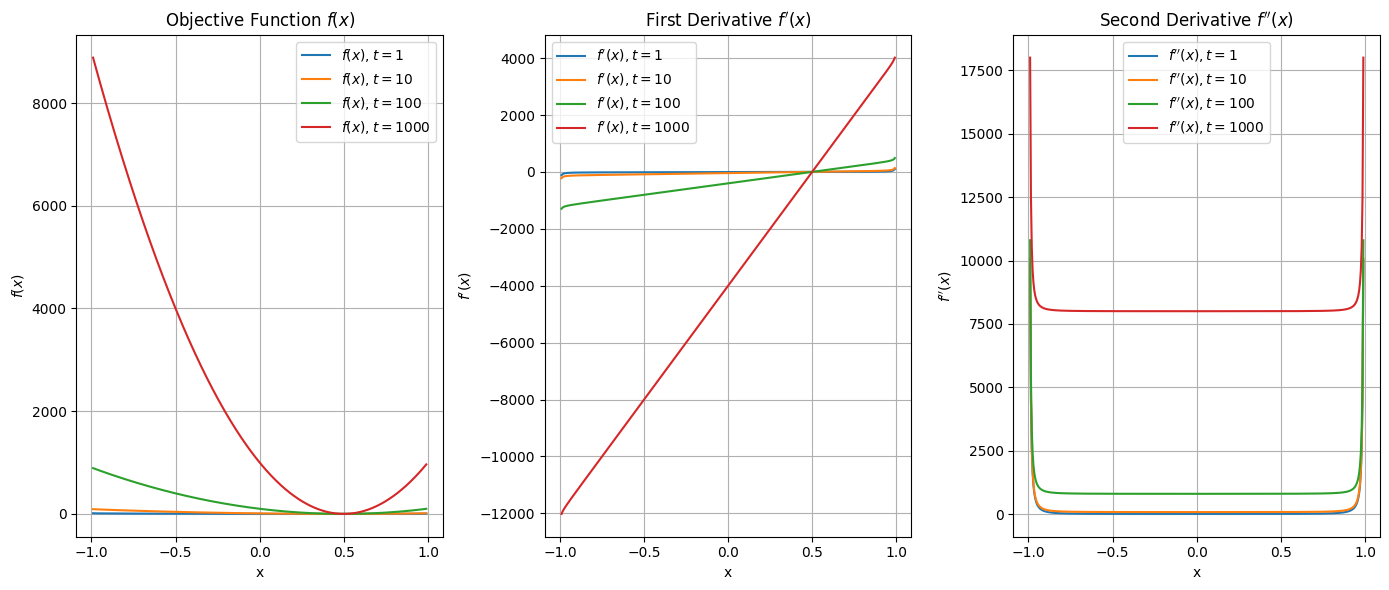

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from autograd import numpy as anp
from autograd import grad, hessian

# Define the objective function including the barrier term
def objective_with_barrier(x, a, b, t):
    barrier_term = -anp.log(1 - x**2)
    return t * (a*x - b)**2 + barrier_term


grad_objective = grad(objective_with_barrier)
hessian_objective = hessian(objective_with_barrier)

# Parameters
a = 2
b = 1
t_values = [1, 10, 100, 1000]  # Different values of t

# Define a range of x values
x_values = anp.linspace(-0.99, 0.99, 400)

# Set up the plot
plt.figure(figsize=(14, 6))


for t in t_values:
    # Compute the function, its first derivative, and its second derivative
    f_values = [objective_with_barrier(x, a, b, t) for x in x_values]
    f_prime_values = [grad_objective(x, a, b, t) for x in x_values]
    f_double_prime_values = [hessian_objective(x, a, b, t) for x in x_values]

    # Plotting
    plt.subplot(1, 3, 1)
    plt.plot(x_values, f_values, label=f'$f(x), t={t}$')
    plt.title('Objective Function $f(x)$')
    plt.xlabel('x')
    plt.ylabel('$f(x)$')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(x_values, f_prime_values, label=f"$f'(x), t={t}$")
    plt.title("First Derivative $f'(x)$")
    plt.xlabel('x')
    plt.ylabel("$f'(x)$")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(x_values, f_double_prime_values, label=f"$f''(x), t={t}$")
    plt.title("Second Derivative $f''(x)$")
    plt.xlabel('x')
    plt.ylabel("$f''(x)$")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


# A Two-dimensional example

[source] (https://towardsdatascience.com/how-to-solve-constrained-optimization-problem-the-interior-point-methods-1733095f9eb5)


Consider a two-dimensional optimization problem, where we minimize
\begin{align*}
\min _{x_1, x_2} f\left(x_1, x_2\right):=\left(x_1-5\right)^2+\left(x_2-6\right)^2
\end{align*}
subject to constraints $h_i\left(x_1, x_2\right)$ :
\begin{align*}
\begin{aligned}
& x_1^2-4 \leq 0 \\
& e^{-x_1}-x_2 \leq 0 \\
& x_1+2 x_2-4 \leq 0 \\
& x_1 \geq 0 \\
& x_2 \geq 0 .
\end{aligned}
\end{align*}

Let's plot the constraint first.

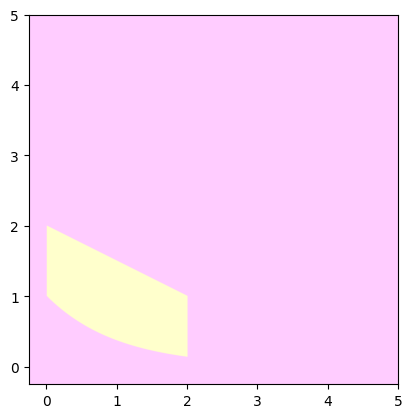

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    '''Function to be minimized'''
    return (x[0]-5)**2 + (x[1]-6)**2

def plot_feasible_set(x, y):
    '''Plot feasible set to be color coded'''
    c1 = lambda a, b : a**2 - 4
    c2 = lambda a, b : np.exp(-a) - b
    c3 = lambda a, b : a + 2*b - 4
    c4 = lambda a, b : -a
    c5 = lambda a, b : -b
    plt.imshow(
        ((c1(x,y)<=0) & (c2(x,y)<=0) & (c3(x,y)<=0) & (c4(x,y)<=0) & (c5(x,y)<=0)).astype(int),
        extent=(x.min(),x.max(),y.min(),y.max()),
        origin='lower',
        cmap='spring',  # Change colormap here
        alpha=0.2  # Set opacity here
    )

def plot_contour(x_min, x_max, y_min, y_max):
    '''Plot contour of the objective function'''
    delta = 0.025
    x = np.arange(x_min, x_max, delta)
    y = np.arange(y_min, y_max, delta)
    x, y = np.meshgrid(x, y)
    z = np.zeros(x.shape)
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x_coor = x[i][j]
            y_coor = y[i][j]
            # Ensure f is called with a 1-dimensional array and directly assign the scalar result
            z[i][j] = f(np.array([x_coor, y_coor]))
    CS = plt.contour(x, y, z)
    plt.clabel(CS, fmt='%1.2f')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('Contour of $f(x)$ along with the Feasible Set and Iteration Path')
    plt.show()


x_min = 0
x_max = 5
y_min = 0
y_max = 5

d = np.linspace(min(x_min, y_min, -0.25), max(x_max, y_max, 2.25), 2000)
x, y = np.meshgrid(d, d)

plot_feasible_set(x, y)


## Barrier method

In barrier method, we construct a barrier function
\begin{align}
\phi(x)=-\sum_{i=1}^m \log \left(-h_i(x)\right),
\end{align}
and consider optimizating
$$
 F_t (x) = t\cdot f(x) + \phi(x)
$$
using Newton's method.

Note that we don't have equality constraints.  So this problem is a uncontrained optimization problem. The gradient and Hessian of this objective is given as follows:

\begin{align*}
\begin{aligned}
& \nabla F_t \left(x_1, x_2\right) =\left[\begin{array}{c}
2\left(x_1-5\right) \cdot t - \left(\frac{-2 x_1}{-x_1^2+4}+\frac{e^{-x_1}}{-e^{-x_1}+x_2}+\frac{-1}{-x_1-2 x_2+4}+\frac{1}{x_1}\right) \\
2\left(x_2-6\right) \cdot t- \left(\frac{1}{-e^{-x_1}+x_2}+\frac{-2}{-x_1-2 x_2+4}+\frac{1}{x_2}\right)
\end{array}\right] \\
& H\left(x_1, x_2\right)=\left[\begin{array}{ll}
A & B \\
C & D
\end{array}\right]
\end{aligned}
\end{align*}
with
\begin{align*}
\begin{aligned}
& A=2 \cdot t- \left(\frac{-2 x_1^2-8}{\left(-x_1^2+4\right)^2}+\frac{-x_2 e^{-x_1}}{\left(-e^{-x_1}+x_2\right)^2}+\frac{-1}{\left(-x_1-2 x_2+4\right)^2}\right) \\
& B=C=- \left(\frac{-e^{-x_1}}{\left(-e^{\left.\left(-x_1\right)+x_2\right)^2}+ \right)} + \frac{-2}{\left(-x_1-2 x_2+4\right)^2}\right). \\
& D=2 \cdot t - \left(\frac{-1}{\left(-e^{-x_1}+x_2\right)^2}+\frac{-4}{\left(-x_1-2 x_2+4\right)^2}\right) .
\end{aligned}
\end{align*}

In [4]:
def g(x, t):
    '''Gradient of t* f(x) +  ϕ(x)'''

    x1, x2 = x

    dcdx1 = []
    dcdx1.append(2*x1 / (x1**2 - 4))
    dcdx1.append(-np.exp(-x1) / (np.exp(-x1) - x2))
    dcdx1.append(1 / (x1 + 2*x2 - 4))
    dcdx1.append(-1 / (-x1))
    dcdx1.append(0 / (-x2))

    dcdx2 = []
    dcdx2.append(0 / (x1**2 - 4))
    dcdx2.append(-1 / (np.exp(-x1) - x2))
    dcdx2.append(2 / (x1 + 2*x2 - 4))
    dcdx2.append(0 / (-x1))
    dcdx2.append(-1 / (-x2))

    dthetadx1 = 0
    dthetadx2 = 0
    for a, b in zip(dcdx1, dcdx2):
        dthetadx1 -= a
        dthetadx2 -= b

    grad = np.zeros(2)
    grad[0] = 2 * (x1-5) * t +  dthetadx1
    grad[1] = 2 * (x2-6) * t+  dthetadx2

    return grad

def H(x, t):
    '''Hessian of f(x) + 1/t * ϕ(x)'''

    x1, x2 = x

    terms = []
    terms.append(x1**2 - 4)
    terms.append(np.exp(-x1) - x2)
    terms.append(x1 + 2*x2 - 4)

    hess = np.zeros((2, 2))
    hess[0][0] = 2*t -  ((-2 * x1**2 - 8)/(terms[0]**2) - \
                            (x2 * np.exp(-x1))/(terms[1]**2) - \
                            1/(terms[2]**2))

    hess[0][1] = -1 * (-np.exp(-x1)/(terms[1]**2) - \
                         2/(terms[2]**2))

    hess[1][0] = hess[0][1]
    hess[1][1] = 2*t - (-1/(terms[1]**2) - 4/(terms[2]**2))

    return hess

Barrier function implements the following two steps:

- Set an initial point $x_0$, initial parameter $t$, and tolerance $\epsilon$ for stopping criterion. Here we will use $\epsilon = 10^{-5}$.

- Do the following a-b-c loop until the stopping criterion is met. The stopping criterion used is the duality gap $m/t ≤ \epsilon$, with $m$ being the number of constraints. In our case, $m = 5$.

  - (a) Minimize $F_t(x)$ starting from the current iterate $x^k$ using Newton's method
  - (b) Let $x^{k+1}$ be the solution
  - (c) Increase $t$ by multipling some number larger than 1

In [5]:
def BarrierMethod(x_init, m, t, nu=0.01, tol_barrier=1e-5, tol_newton = 1e-5, stepsize_newton = 1, max_iter=1000):
    '''Main algorithm for Barrier Method'''

    x = x_init               # store initial value
    xs = [x]                 # initialize tabulation of x for each iteration
    fs = [f(x)]              # initialize tabulation of function value at x
    duality_gap = [m/t]      # initialize tabulation of duality gap
    k = 0                    # number of iterations
    print(f'Initial condition: x = {x}, f(x) = {fs[k]:.4f}\n')

    # loop until stopping criterion is met
    while m / t > tol_barrier:
        # centering step: Newton Algorithm
        i = 0
        d = np.array([[1], [1]])

        # Note: the initialization of newton is the solution to previous subproblem
        while np.linalg.norm(d) > tol_newton and i < max_iter:
            gx = g(x, t)
            Hx = H(x, t)
            d = -np.dot(np.linalg.inv(Hx), gx)
            x = x + stepsize_newton * d
            xs.append(x)
            i += 1

        # update parameter t
        t = (1 + 1/(20 * np.sqrt(nu))) * t # t = 1.5 t

        # update tabulations
        duality_gap.append(m/t)
        fs.append(f(x))
        k += 1

        # print result
        print(f'Iteration: {k} \t x = {x}, f(x) = {fs[k]:.4f}, gap = {duality_gap[k]:.4f}')

    xs = np.array(xs)
    return xs, fs, duality_gap

Define a function that plots the function curve

In [6]:


def plot_learning_curve(fs, duality_gap):
    '''Plot learning curve of the algorithm'''
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
    ax1.plot(fs, c='m')
    ax1.scatter(len(fs)-1, fs[-1], c='c')
    ax1.set(
        title='$f(x)$ for each Iteration',
        xlabel='Number of Iterations',
        ylabel='$f(x)$',
        xlim=0
    )
    ax2.plot(duality_gap, c='m')
    ax2.scatter(len(duality_gap)-1, duality_gap[-1], c='c')
    ax2.set(
        title='Duality Gap for each Iteration',
        xlabel='Number of Iterations',
        ylabel='Duality Gap',
        xlim=0
    )
    plt.show()


def plot_all(xs, fs, duality_gap):
    '''Plot all results'''

    plt.figure(figsize=(10, 10))
    plt.plot(xs[:,0], xs[:,1], 'm')
    plt.scatter(xs[1:-1,0], xs[1:-1,1], color='#88c999')
    plt.scatter(xs[-1][0], xs[-1][1], color='c') # end
    plt.scatter(xs[0][0], xs[0][1], color='r') # initialization
    x_min, x_max = plt.gca().get_xlim()
    y_min, y_max = plt.gca().get_ylim()
    d = np.linspace(min(x_min, y_min, -0.25), max(x_max, y_max, 2.25), 2000)
    x, y = np.meshgrid(d, d)

    plot_feasible_set(x, y)
    plot_contour(x.min(), x.max(), y.min(), y.max())
    plot_learning_curve(fs, duality_gap)

Now we test this method for a few different initializations

(a) Initial values x = (0.50, 0.75) and t = 0.1

(b) Initial values x = (0.50, 0.75) and t = 1

(c) Initial values x = (1.50, 2.00) and t = 0.1

Initial condition: x = [0.5  0.75], f(x) = 47.8125

Iteration: 1 	 x = [1.02021232 1.16420229], f(x) = 39.2236, gap = 33.3333
Iteration: 2 	 x = [1.0792539  1.17444069], f(x) = 38.6583, gap = 22.2222
Iteration: 3 	 x = [1.15784765 1.18117931], f(x) = 37.9832, gap = 14.8148
Iteration: 4 	 x = [1.2549369  1.18082193], f(x) = 37.2500, gap = 9.8765
Iteration: 5 	 x = [1.36434524 1.17150465], f(x) = 36.5324, gap = 6.5844
Iteration: 6 	 x = [1.47647394 1.15430319], f(x) = 35.8960, gap = 4.3896
Iteration: 7 	 x = [1.58218988 1.13228527], f(x) = 35.3761, gap = 2.9264
Iteration: 8 	 x = [1.67551479 1.10877029], f(x) = 34.9763, gap = 1.9509
Iteration: 9 	 x = [1.75391637 1.08628021], f(x) = 34.6817, gap = 1.3006
Iteration: 10 	 x = [1.81731292 1.06632948], f(x) = 34.4706, gap = 0.8671
Iteration: 11 	 x = [1.86699323 1.04960094], f(x) = 34.3222, gap = 0.5781
Iteration: 12 	 x = [1.90486557 1.03619884], f(x) = 34.2192, gap = 0.3854
Iteration: 13 	 x = [1.93301799 1.02586817], f(x) = 34.1484, gap =

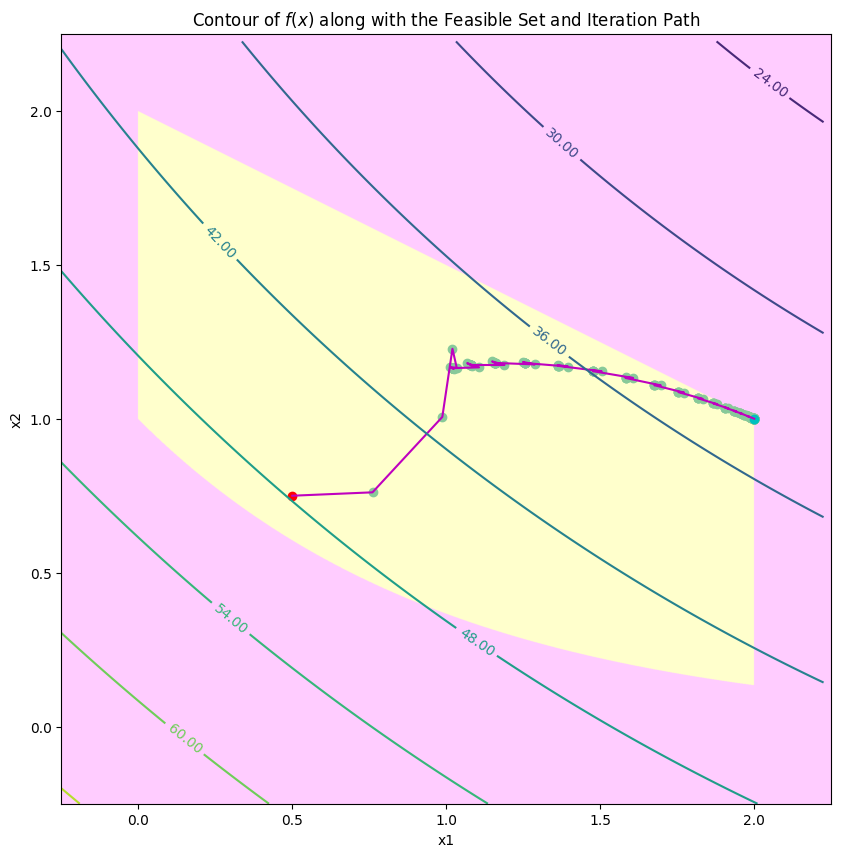

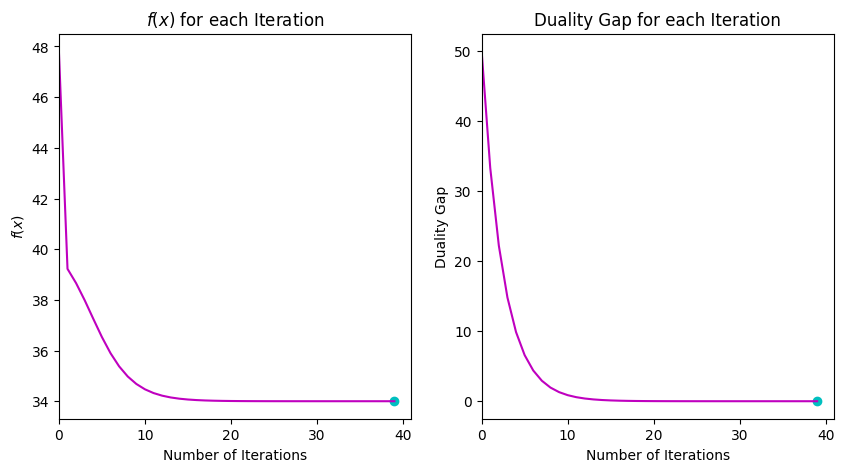

In [7]:
x_init = np.array([0.50, 0.75])
xs, fs, duality_gap = BarrierMethod(x_init, 5, 0.1)
plot_all(xs, fs, duality_gap)

### (b) Initial values x = (0.50, 0.75) and t = 1


Initial condition: x = [0.5  0.75], f(x) = 47.8125

Iteration: 1 	 x = [5.34749659 6.23289449], f(x) = 0.1750, gap = 3.3333
Iteration: 2 	 x = [5.23754152 6.1575069 ], f(x) = 0.0812, gap = 2.2222
Iteration: 3 	 x = [5.16120987 6.10605536], f(x) = 0.0372, gap = 1.4815
Iteration: 4 	 x = [5.10882027 6.07118795], f(x) = 0.0169, gap = 0.9877
Iteration: 5 	 x = [5.073172   6.04767941], f(x) = 0.0076, gap = 0.6584
Iteration: 6 	 x = [5.04906759 6.03188609], f(x) = 0.0034, gap = 0.4390
Iteration: 7 	 x = [5.03284157 6.02130228], f(x) = 0.0015, gap = 0.2926
Iteration: 8 	 x = [5.02195289 6.01422163], f(x) = 0.0007, gap = 0.1951
Iteration: 9 	 x = [5.01466151 6.00949007], f(x) = 0.0003, gap = 0.1301
Iteration: 10 	 x = [5.00978608 6.00633072], f(x) = 0.0001, gap = 0.0867
Iteration: 11 	 x = [5.00652929 6.00422226], f(x) = 0.0001, gap = 0.0578
Iteration: 12 	 x = [5.00435519 6.00281564], f(x) = 0.0000, gap = 0.0385
Iteration: 13 	 x = [5.0029045  6.00187744], f(x) = 0.0000, gap = 0.0257
Iteratio

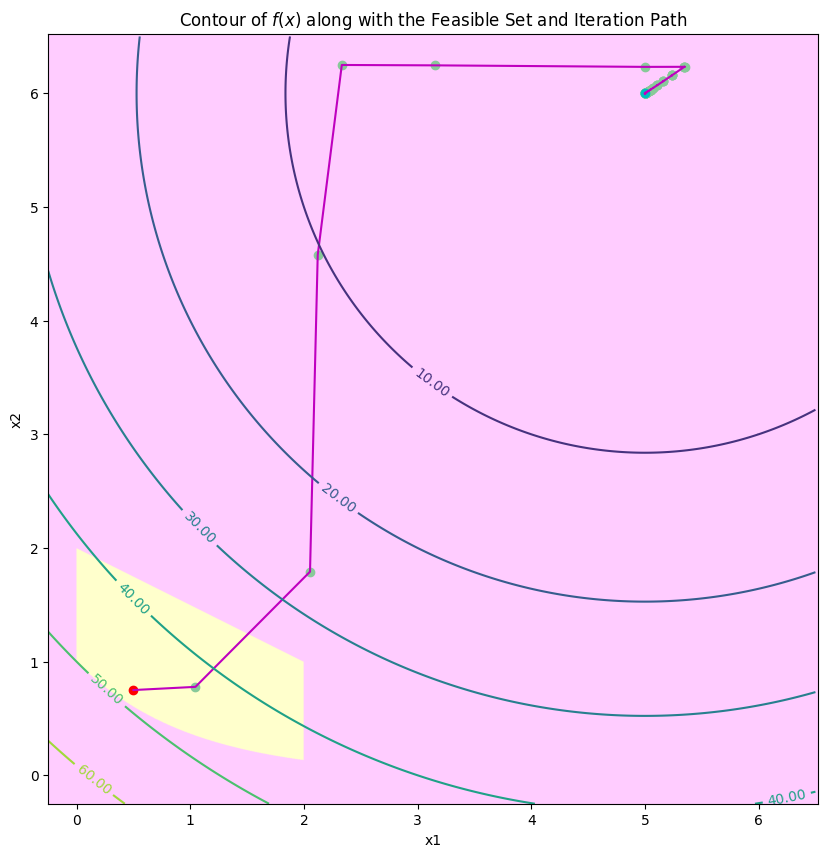

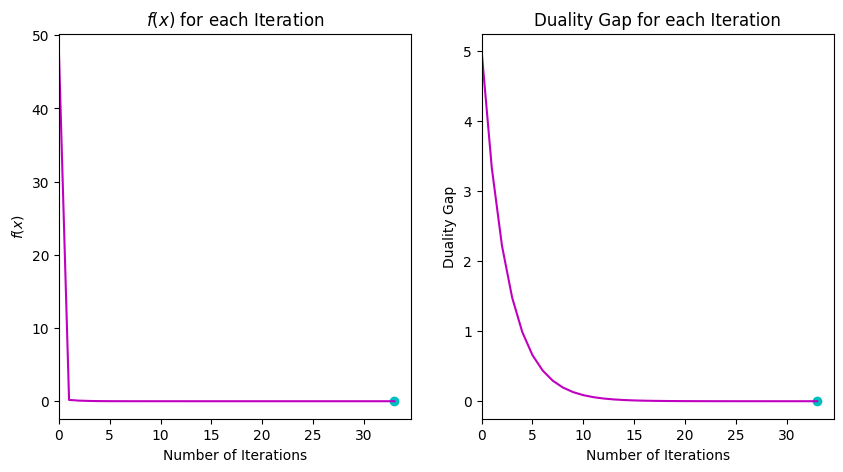

In [8]:


x_init = np.array([0.50, 0.75])
xs, fs, duality_gap = BarrierMethod(x_init, 5, 1)
plot_all(xs, fs, duality_gap)


A solution is found to be x* = (5, 6) with f(x) = 0 after 23 iterations. However, since the initial t is too big, at some point in the iteration process, the temporary iterate x broke through the feasible set, and the iterations that follow try to find a solution outside the feasible set, which we know is (5, 6).

*Reason:* Newton step  has a large stepsize. Newton update actually don't know the value of barrier function, it only work on the gradient and hessian. You can still plug the gradient function and evaluate it outside of the feasible set. This means that, in newton step, we should not just use constant stepsize = 1. Either use line search or choose a smaller stepsize.



Initial condition: x = [0.5  0.75], f(x) = 47.8125

Iteration: 1 	 x = [1.86103593 6.25818665], f(x) = 9.9198, gap = 3.3333
Iteration: 2 	 x = [1.9019457 6.1743523], f(x) = 9.6283, gap = 2.2222
Iteration: 3 	 x = [1.93197501 6.11725524], f(x) = 9.4265, gap = 1.4815
Iteration: 4 	 x = [1.95338387 6.07863585], f(x) = 9.2881, gap = 0.9877
Iteration: 5 	 x = [1.96833218 6.05263288], f(x) = 9.1938, gap = 0.6584
Iteration: 6 	 x = [1.97861634 6.03518444], f(x) = 9.1300, gap = 0.4390
Iteration: 7 	 x = [1.98562092 6.02349824], f(x) = 9.0870, gap = 0.2926
Iteration: 8 	 x = [1.99035783 6.01568611], f(x) = 9.0582, gap = 0.1951
Iteration: 9 	 x = [1.9935469  6.01046576], f(x) = 9.0389, gap = 0.1301
Iteration: 10 	 x = [1.99568634 6.00698259], f(x) = 9.0259, gap = 0.0867
Iteration: 11 	 x = [1.99711868 6.00465898], f(x) = 9.0173, gap = 0.0578
Iteration: 12 	 x = [1.99807689 6.00310673], f(x) = 9.0116, gap = 0.0385
Iteration: 13 	 x = [1.99871644 6.00207351], f(x) = 9.0077, gap = 0.0257
Iteration:

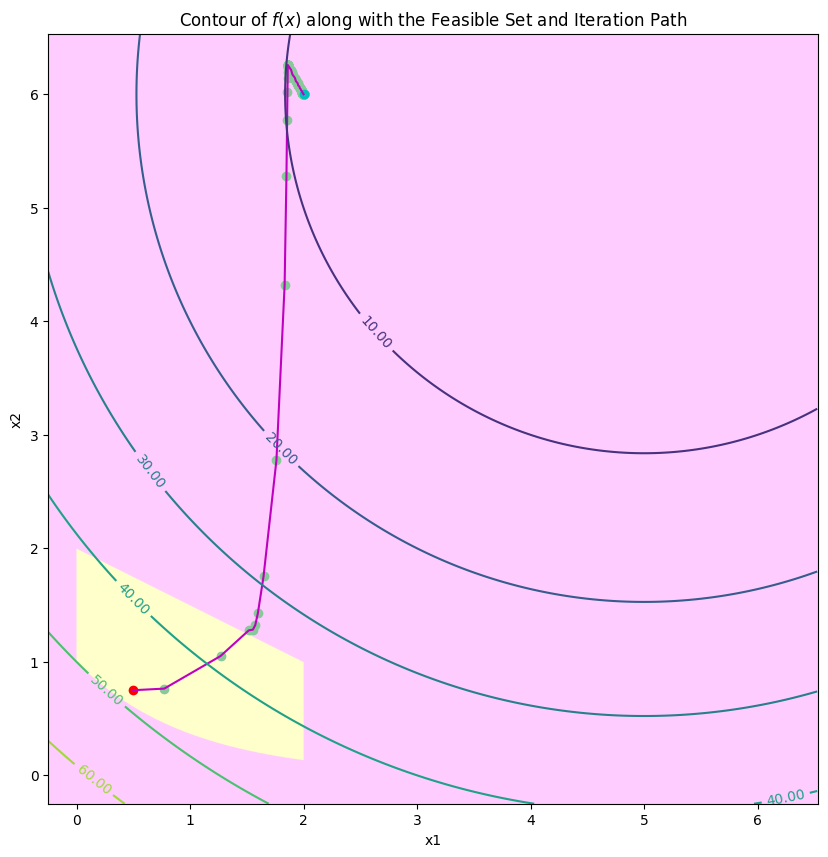

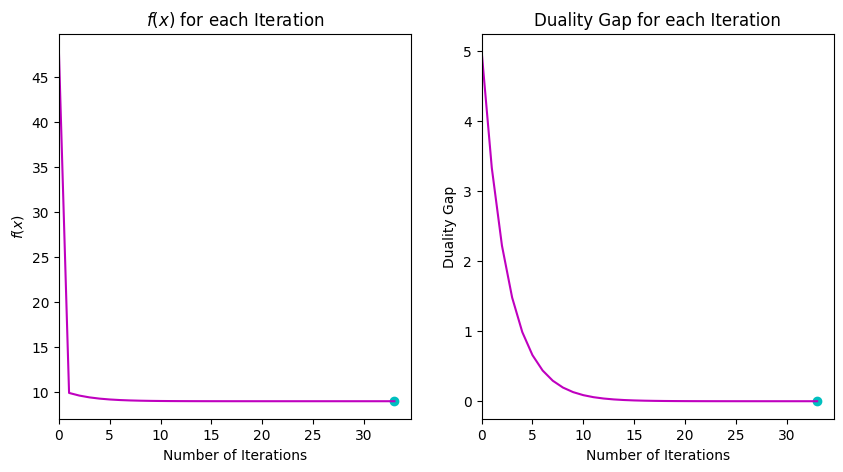

In [9]:
x_init = np.array([0.50, 0.75])
xs, fs, duality_gap = BarrierMethod(x_init, m = 5, t = 1, stepsize_newton = 0.5)
plot_all(xs, fs, duality_gap)

Initial condition: x = [0.5  0.75], f(x) = 47.8125

Iteration: 1 	 x = [1.86103591 6.2581853 ], f(x) = 9.9198, gap = 3.3333
Iteration: 2 	 x = [1.9019455  6.17435235], f(x) = 9.6283, gap = 2.2222
Iteration: 3 	 x = [1.93197421 6.11725743], f(x) = 9.4265, gap = 1.4815
Iteration: 4 	 x = [1.95338387 6.07863512], f(x) = 9.2881, gap = 0.9877
Iteration: 5 	 x = [1.96833165 6.05263409], f(x) = 9.1938, gap = 0.6584
Iteration: 6 	 x = [1.97861592 6.0351851 ], f(x) = 9.1300, gap = 0.4390
Iteration: 7 	 x = [1.98561997 6.02350086], f(x) = 9.0870, gap = 0.2926
Iteration: 8 	 x = [1.99035766 6.01568597], f(x) = 9.0582, gap = 0.1951
Iteration: 9 	 x = [1.99354629 6.01046729], f(x) = 9.0389, gap = 0.1301
Iteration: 10 	 x = [1.99568579 6.00698374], f(x) = 9.0260, gap = 0.0867
Iteration: 11 	 x = [1.99711825 6.00465951], f(x) = 9.0173, gap = 0.0578
Iteration: 12 	 x = [1.99807592 6.00310934], f(x) = 9.0116, gap = 0.0385
Iteration: 13 	 x = [1.99871629 6.00207323], f(x) = 9.0077, gap = 0.0257
Iteratio

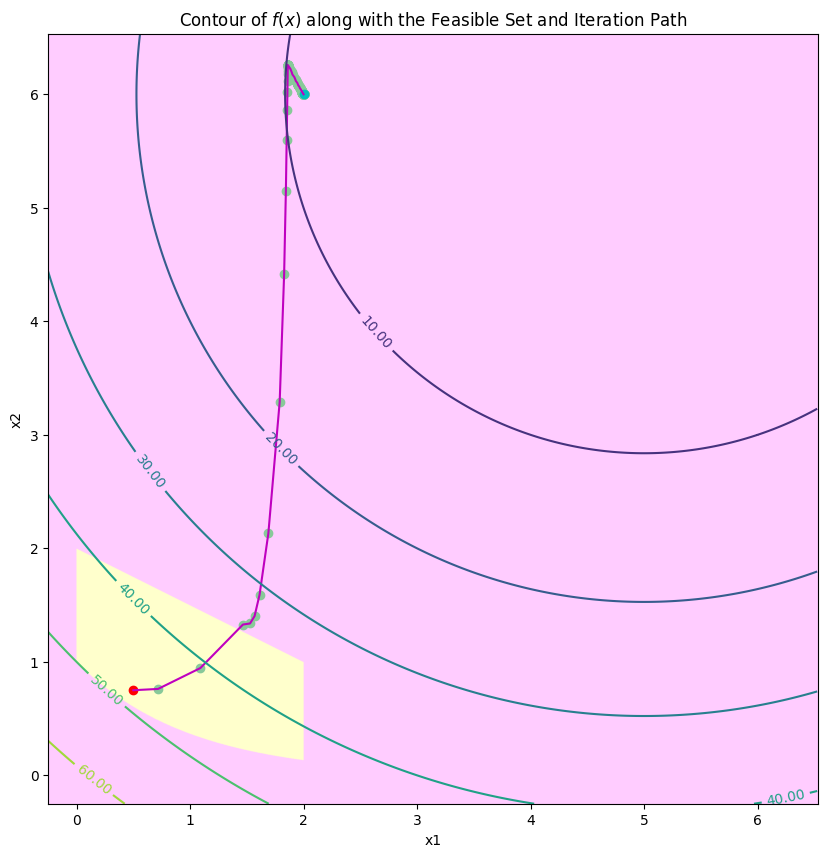

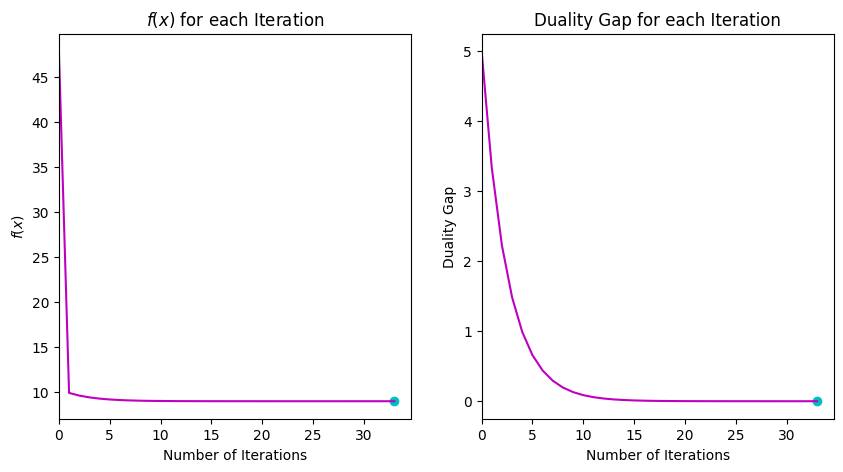

In [10]:
x_init = np.array([0.50, 0.75])
xs, fs, duality_gap = BarrierMethod(x_init, m = 5, t = 1, stepsize_newton = 0.4)
plot_all(xs, fs, duality_gap)

Initial condition: x = [0.5  0.75], f(x) = 47.8125

Iteration: 1 	 x = [1.54937519 1.13966835], f(x) = 35.5296, gap = 3.3333
Iteration: 2 	 x = [1.64710675 1.11631097], f(x) = 35.0923, gap = 2.2222
Iteration: 3 	 x = [1.73040324 1.09328039], f(x) = 34.7662, gap = 1.4815
Iteration: 4 	 x = [1.79852377 1.07240564], f(x) = 34.5306, gap = 0.9877
Iteration: 5 	 x = [1.85242026 1.05460792], f(x) = 34.3642, gap = 0.6584
Iteration: 6 	 x = [1.89385868 1.04015228], f(x) = 34.2482, gap = 0.4390
Iteration: 7 	 x = [1.92490509 1.02887775], f(x) = 34.1683, gap = 0.2926
Iteration: 8 	 x = [1.94762059 1.02038465], f(x) = 34.1136, gap = 0.1951
Iteration: 9 	 x = [1.96389262 1.01417251], f(x) = 34.0764, gap = 0.1301
Iteration: 10 	 x = [1.97534035 1.0097374 ], f(x) = 34.0513, gap = 0.0867
Iteration: 11 	 x = [1.98327703 1.00663093], f(x) = 34.0344, gap = 0.0578
Iteration: 12 	 x = [1.98871759 1.00448641], f(x) = 34.0230, gap = 0.0385
Iteration: 13 	 x = [1.99241586 1.00302165], f(x) = 34.0154, gap = 0.

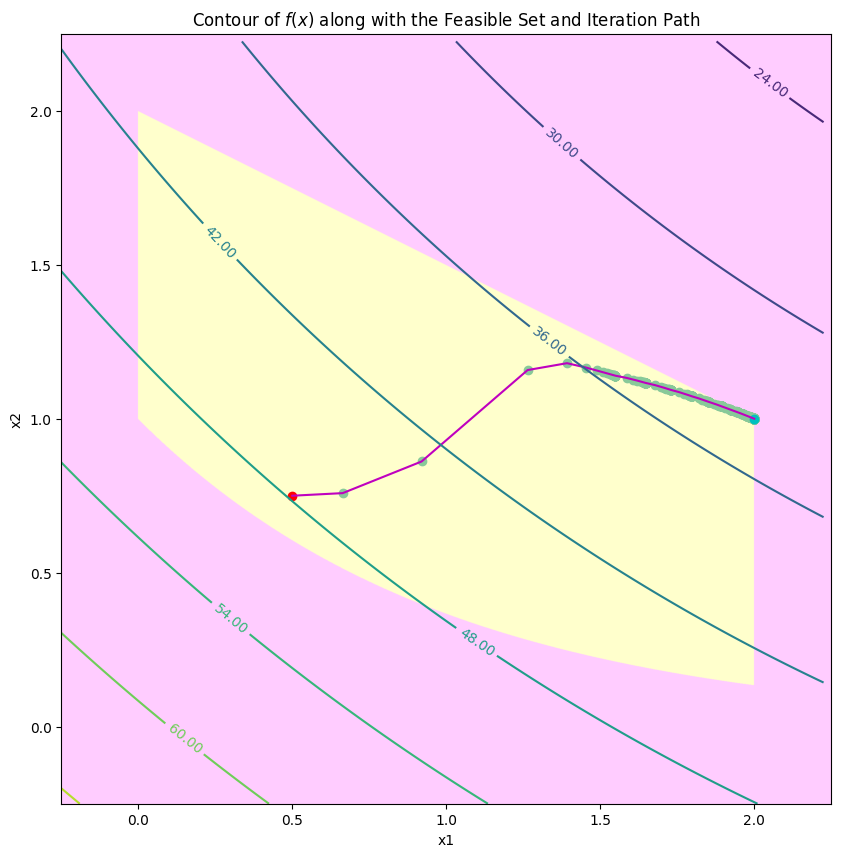

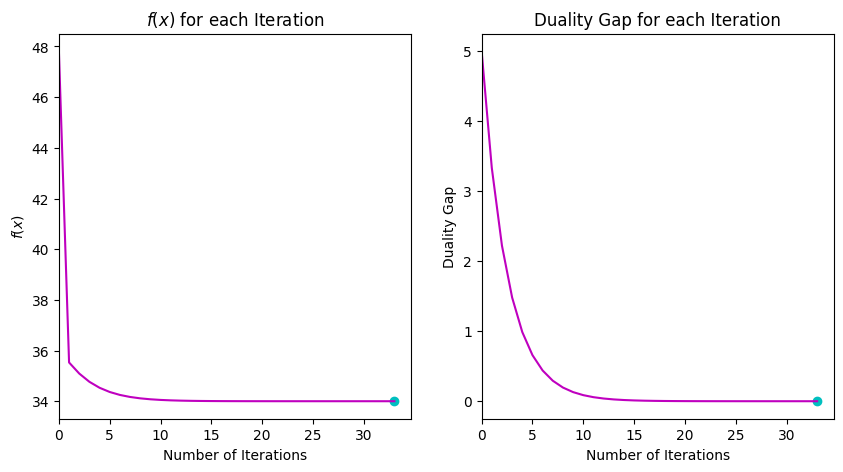

In [11]:
x_init = np.array([0.50, 0.75])
xs, fs, duality_gap = BarrierMethod(x_init, m = 5, t = 1, stepsize_newton = 0.3)
plot_all(xs, fs, duality_gap)

### (c) Initial values x = (1.50, 2.00) and t = 0.1

In this case, the initalization is not feasible.



Initial condition: x = [1.5 2. ], f(x) = 28.2500

Iteration: 1 	 x = [1.44403603 8.01008369], f(x) = 16.6853, gap = 33.3333
Iteration: 2 	 x = [1.52258661 7.44587518], f(x) = 14.1830, gap = 22.2222
Iteration: 3 	 x = [1.60659956 7.02347983], f(x) = 12.5627, gap = 14.8148
Iteration: 4 	 x = [1.68907602 6.71406835], f(x) = 11.4721, gap = 9.8765
Iteration: 5 	 x = [1.76358054 6.49217128], f(x) = 10.7166, gap = 6.5844
Iteration: 6 	 x = [1.82610693 6.33598952], f(x) = 10.1865, gap = 4.3896
Iteration: 7 	 x = [1.87548698 6.22772654], f(x) = 9.8144, gap = 2.9264
Iteration: 8 	 x = [1.91267012 6.15355049], f(x) = 9.5552, gap = 1.9509
Iteration: 9 	 x = [1.93968122 6.10315958], f(x) = 9.3762, gap = 1.3006
Iteration: 10 	 x = [1.95879479 6.06913206], f(x) = 9.2537, gap = 0.8671
Iteration: 11 	 x = [1.97206931 6.0462496 ], f(x) = 9.1705, gap = 0.5781
Iteration: 12 	 x = [1.98116875 6.03090547], f(x) = 9.1143, gap = 0.3854
Iteration: 13 	 x = [1.98735026 6.020636  ], f(x) = 9.0765, gap = 0.2569
I

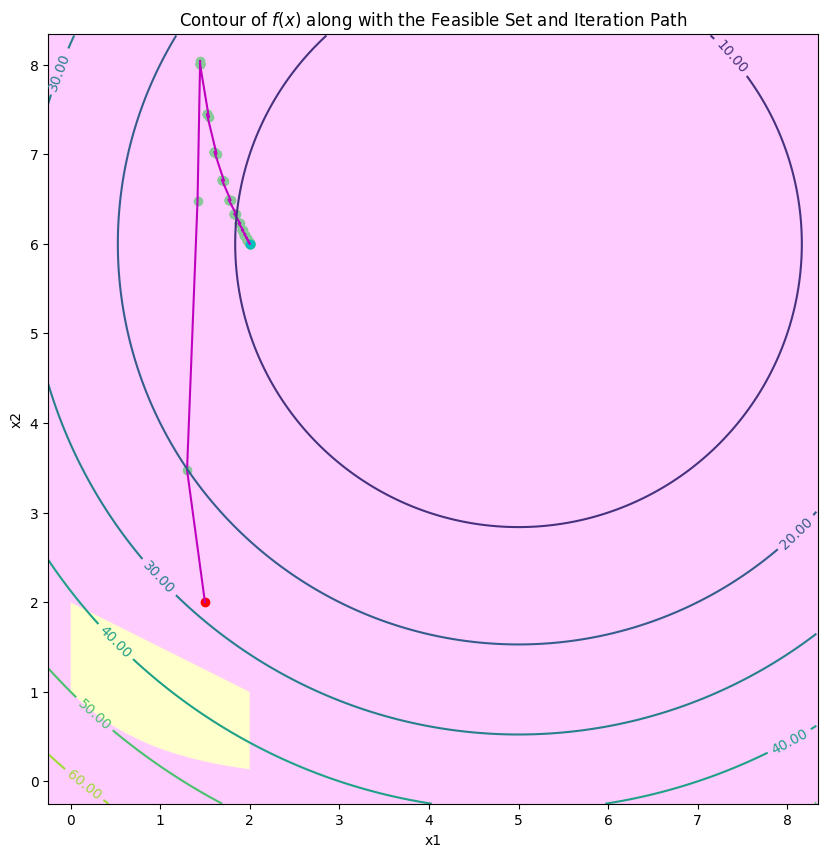

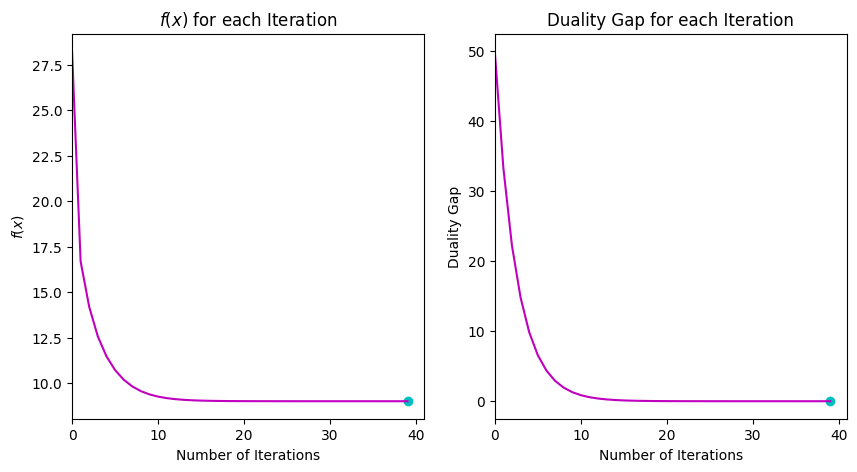

In [12]:
x_init = np.array([1.5, 2])
xs, fs, duality_gap = BarrierMethod(x_init, 5, 0.1)
plot_all(xs, fs, duality_gap)

## Primal-dual interior point

Primal-dual interior point method involves solving the Karush-Kuhn-Tucker (KKT) conditions for the optimization problem with inequality constraints. This method allows for infeasible starting points, unlike the pure barrier method which requires a feasible starting point.

For this problem, we introduce five dual variables for the inequality constraints. We want to solve
Then we want to solve the KKT
\begin{align}
\begin{gathered}
r(x, u, v)=\left(\begin{array}{c}
\nabla f(x)+D h(x)^T u  \\
-\operatorname{diag}(u) h(x)-1 / t
\end{array}\right) = 0\\
h(x)=\left(\begin{array}{c}
h_1(x) \\
\cdots \\
h_m(x)
\end{array}\right), \quad D h(x)=\left[\begin{array}{c}
\nabla h_1(x)^T \\
\cdots \\
\nabla h_m(x)^T
\end{array}\right]
\end{gathered}
\end{align}

We define the constraint $h$ and its Jacobian. Then compute the residue of KKT.

In [13]:
def h(x):
    """Constraints vector"""
    return np.array([
        x[0]**2 - 4,
        np.exp(-x[0]) - x[1],
        x[0] + 2*x[1] - 4,
        -x[0],
        -x[1]
    ])

def Dh(x):
    """Jacobian matrix of the constraints"""
    return np.array([
        [2*x[0], 0],
        [-np.exp(-x[0]), -1],
        [1, 2],
        [-1, 0],
        [0, -1]
    ])


def r(x, u, t):
    """Computes the residuals of the KKT conditions"""
    grad_f = np.array([2*(x[0]-5), 2*(x[1]-6)])  # Gradient of the objective function
    Dh_x = Dh(x)  # Jacobian of the constraints

    u = np.array(u).flatten()

    DhT_u = Dh_x.T @ u  # Correct matrix multiplication: (2, m) @ (m,) -> (2,)
    diag_u_hx = -np.multiply(u, h(x)) - (1 / t)  # Element-wise multiplication

    r_dual = grad_f + DhT_u
    r_cent = diag_u_hx

    return r_dual, r_cent

Next, we compute the Hessian

In [14]:
def Hessian_f(x):
    """Hessian of the objective function f(x)"""
    return np.array([[2.0, 0], [0, 0]])

def Hessian_hi(x, i):
    """Second derivatives of the constraint functions, h_i(x)"""
    if i == 1:  # x1^2 - 4
        return np.array([[2.0, 0], [0, 0]])
    elif i == 2:  # exp(-x1) - x2
        return np.array([[np.exp(-x[0]), 0], [0, 0]])
    elif i == 3:  # x1 + 2*x2 - 4
        return np.zeros((2, 2))  # Linear constraint, second derivative is 0
    elif i == 4:  # -x1
        return np.zeros((2, 2))  # Linear constraint, second derivative is 0
    elif i == 5:  # -x2
        return np.zeros((2, 2))  # Linear constraint, second derivative is 0


Then, solve for the update direction:
\begin{align}
\begin{gathered}
{\left[\begin{array}{ccc}
\nabla^2 f(x)+\sum_{i=1}^m u_i \nabla^2 h_i(x) & D h(x)^T & A^T \\
-\operatorname{diag}(u) D h(x) & -\operatorname{diag}(h(x)) & 0
\end{array}\right]\left(\begin{array}{c}
\Delta x \\
\Delta u  
\end{array}\right)}  
=-\left(\begin{array}{c}
r_{\text {dual }} \\
r_{\text {cent }}  
\end{array}\right)
\end{gathered}
\end{align}


In [15]:
def Hessian_Lagrangian(x, u):
    H_L = Hessian_f(x)
    for i in range(len(u)):
        H_L += u[i] * Hessian_hi(x, i+1)  # i+1 because constraints are 1-indexed in the explanation
    return H_L

def solve_KKT(x, u, t):
    # Compute residuals
    r_dual, r_pri = r(x, u, t)
    r_cent = -np.diag(u).dot(h(x)) - (1 / t)

    # Form the KKT matrix
    Dh_x = Dh(x)
    H_L = Hessian_Lagrangian(x, u)
    zero_block = np.zeros((len(u), len(u)))
    # print(np.shape(H_L))
    # print(np.shape(Dh_x.T))
    # print(np.shape(-np.diag(u).dot(Dh_x)))
    # print(np.shape(-np.diag(h(x))))
    upper_block = np.hstack((H_L, Dh_x.T))
    lower_block = np.hstack((-np.diag(u).dot(Dh_x), -np.diag(h(x))))
    KKT_matrix = np.vstack((upper_block, lower_block))

    # Form the RHS of the KKT system
    rhs = -np.hstack((r_dual, r_cent))

    # Solve the linear system for the search direction
    delta = np.linalg.solve(KKT_matrix, rhs)

    # Extract delta_x and delta_u from the solution
    delta_x = delta[:len(x)]
    delta_u = delta[len(x):]

    return delta_x, delta_u




In [16]:
def PrimalDualInteriorPoint(x_init, u_init, m,  mu = 1.5, tol=1e-5,  stepsize = 1, max_iter=1000):
    '''Main algorithm for Primal-Dual Interior Point Method'''
    x = x_init  # Initial guess for x
    u = u_init  # Initial guess for dual variables
    eta_sequence = []  # To store the sequence of eta values
    xs = [x.copy()]  # To store iterates of x
    fs = [f(x)]  # To store function values
    k = 0  # Iteration counter


    for k in range(max_iter):
        eta = -np.sum(u * h(x))  # Calculate eta
        eta_sequence.append(eta)  # Store eta value

        # Update t based on eta
        t = mu * m / eta
        print(f'The value of t is {t:.4f}')
        # Solve for search direction using Newton's method
        delta_x, delta_u = solve_KKT(x, u, t)

        # Compute residuals for convergence check
        r_dual, r_pri = r(x, u, t)
        r_norm = np.linalg.norm(np.hstack((r_dual, r_pri)), ord=2)

        # Check convergence criteria
        if eta < tol and r_norm < tol:
            print("Convergence achieved.")
            break

        # Update x and u using the search direction
        x += stepsize * delta_x
        u += stepsize * delta_u
        # Store the updated values
        xs.append(x.copy())
        fs.append(f(x))

        # Print the current iteration results
        print(f'Iteration: {k+1} \t x = {x}, f(x) = {fs[-1]:.4f}, duality gap = {eta:.4f}')


    return np.array(xs), np.array(fs), np.array(eta_sequence)


The value of t is 0.9047
Iteration: 1 	 x = [1.47300063 0.69247439], f(x) = 40.6096, duality gap = 8.2903
The value of t is 0.7059
Iteration: 2 	 x = [1.48536969 0.88283702], f(x) = 38.5380, duality gap = 10.6251
The value of t is 0.8254
Iteration: 3 	 x = [1.48928312 1.00128796], f(x) = 37.3123, duality gap = 9.0867
The value of t is 0.9392
Iteration: 4 	 x = [1.49778525 1.06066556], f(x) = 36.6625, duality gap = 7.9856
The value of t is 1.0531
Iteration: 5 	 x = [1.51173807 1.09183808], f(x) = 36.2580, duality gap = 7.1221
The value of t is 1.1745
Iteration: 6 	 x = [1.52982646 1.10833151], f(x) = 35.9705, duality gap = 6.3857
The value of t is 1.3071
Iteration: 7 	 x = [1.5506955  1.11638574], f(x) = 35.7474, duality gap = 5.7377
The value of t is 1.4534
Iteration: 8 	 x = [1.57323728 1.11928464], f(x) = 35.5641, duality gap = 5.1605
The value of t is 1.6151
Iteration: 9 	 x = [1.59660597 1.11893189], f(x) = 35.4079, duality gap = 4.6436
The value of t is 1.7944
Iteration: 10 	 x = 

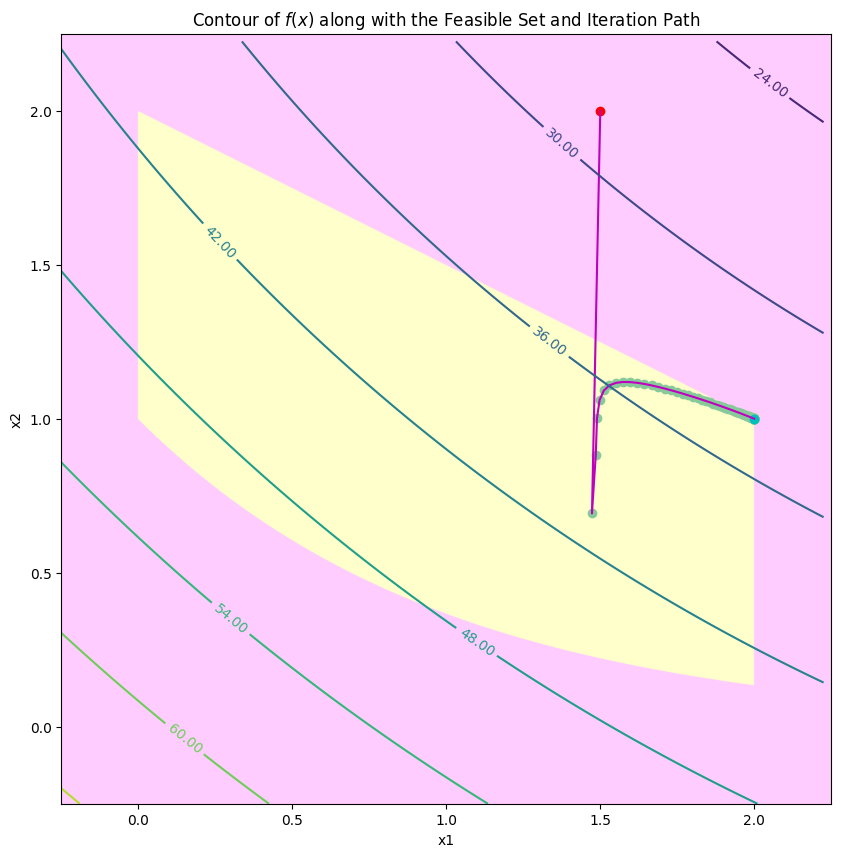

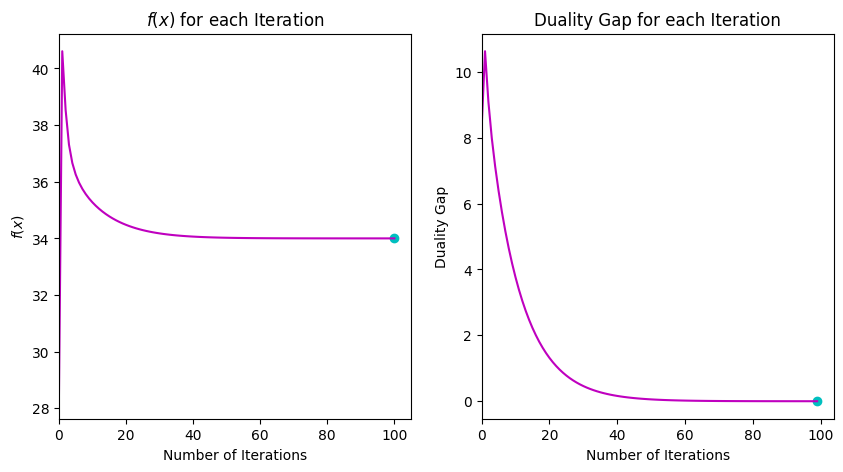

In [17]:
x_init = np.array([1.5, 2])
u_init = 1.5 * np.ones(5)
xs, fs, duality_gap = PrimalDualInteriorPoint(x_init,u_init, m=5, tol = 1e-5, stepsize = 0.3, max_iter=100)
plot_all(xs, fs, duality_gap)